# DS605 - Lab Assignment 3
### Scikit-learn: Data Preprocessing and Model Performance Evaluation

ID: 202618039



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')

RANDOM_STATE = 42


## Part A - Data Loading and Preprocessing

### Task 1 - Load and understand the data

In [2]:
df = pd.read_csv('hotel_bookings.csv')
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
print(df.shape)
df.info()


(119390, 32)
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal          

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


In [5]:
df.dtypes


hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [6]:
# target column
df['is_canceled'].value_counts()


is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [7]:
df['is_canceled'].value_counts(normalize=True) * 100
# roughly 63/37 split, not too imbalanced so no need for extra resampling


is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

In [8]:
y = df['is_canceled']
X = df.drop(columns=['is_canceled'])

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('categorical:', len(cat_cols))
print(cat_cols)
print()
print('numerical:', len(num_cols))
print(num_cols)


categorical: 12
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']

numerical: 19
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


C:\Users\Raaj Soni\AppData\Local\Temp\ipykernel_98732\1060719273.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


### Task 2 - Missing values, leakage columns, outliers

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table = missing_table[missing_table['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_table


,missing_count,missing_pct
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


`company` is missing for around 94% of rows and `agent` for about 14%.
`company` is dropped since it's almost entirely empty and not very useful for a cancellation model.
`agent` is kept - it's a booking-agent id, missingness there just means the booking wasn't made
through an agent, so it's imputed instead of dropped.
`country` and `children` also have a small amount of missing values and are kept.

In [10]:
cols_to_drop_missing = ['company']
df = df.drop(columns=cols_to_drop_missing)
df.shape


(119390, 31)

Now removing the columns that leak the final outcome directly (they basically tell you the answer).

In [11]:
leakage_cols = ['reservation_status', 'reservation_status_date']
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])
df.shape


(119390, 29)

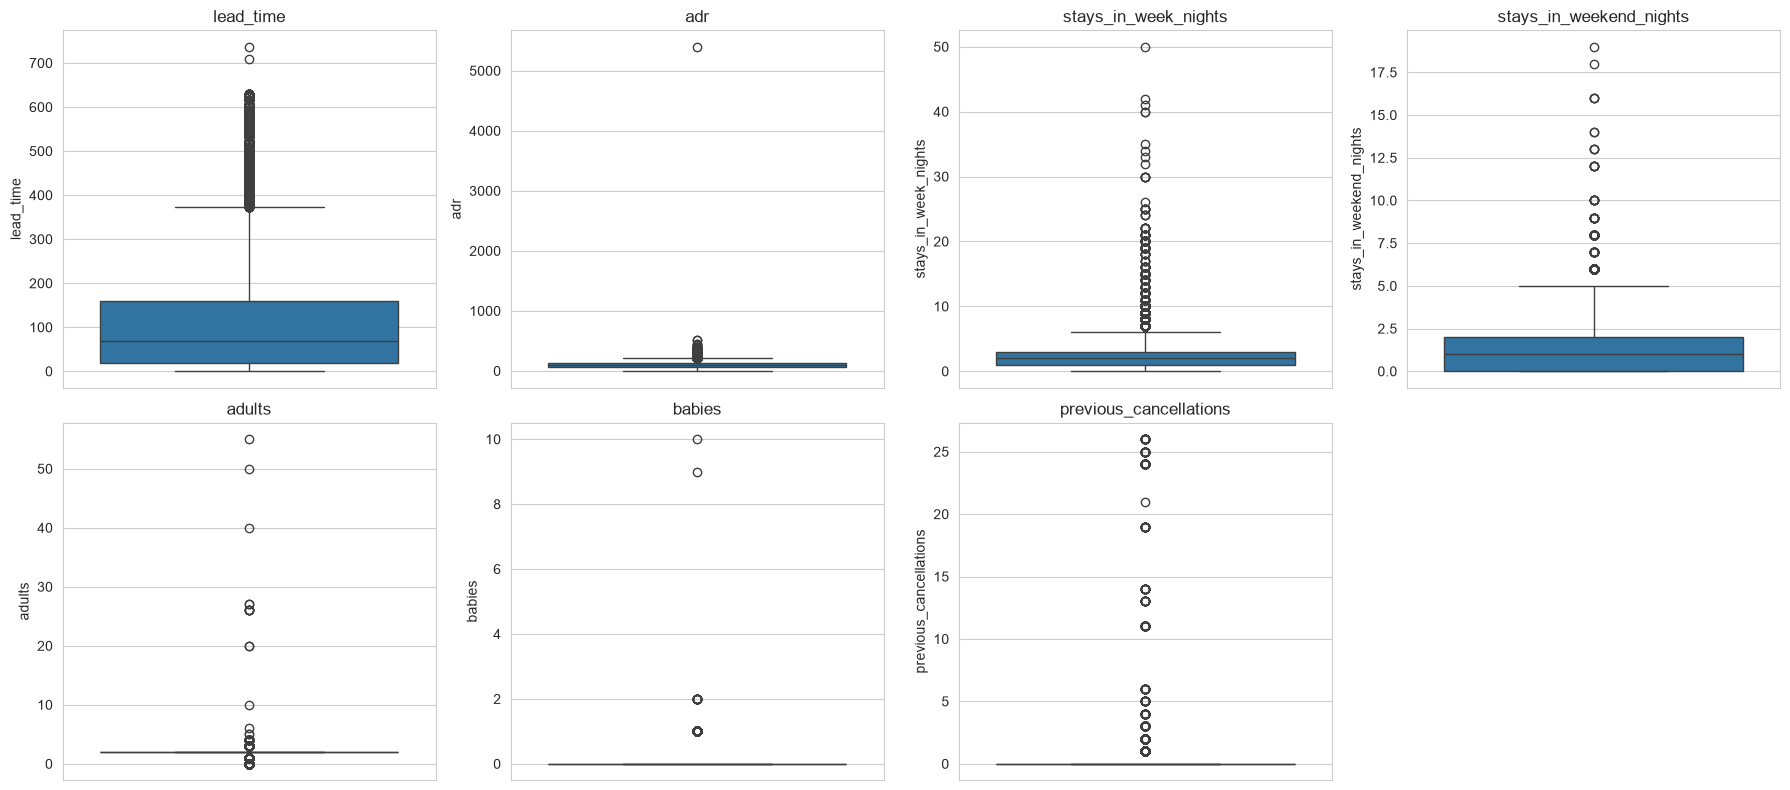

In [12]:
outlier_check_cols = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
                      'adults', 'babies', 'previous_cancellations']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(outlier_check_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


In [13]:
def iqr_bounds(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

# checking counts before deciding what to actually cut
for col in outlier_check_cols:
    low, high = iqr_bounds(df[col])
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f'{col}: bounds=({low:.1f}, {high:.1f}) -> {n_out} rows outside')


lead_time: bounds=(-195.0, 373.0) -> 3005 rows outside
adr: bounds=(-15.8, 211.1) -> 3793 rows outside
stays_in_week_nights: bounds=(-2.0, 6.0) -> 3354 rows outside
stays_in_weekend_nights: bounds=(-3.0, 5.0) -> 265 rows outside
adults: bounds=(2.0, 2.0) -> 29710 rows outside
babies: bounds=(0.0, 0.0) -> 917 rows outside
previous_cancellations: bounds=(0.0, 0.0) -> 6484 rows outside


Only cutting the really extreme, clearly-wrong values instead of everything the IQR rule flags
(the IQR rule flags a lot of normal-ish bookings too, especially for `adr` and `lead_time`, which would
throw away too much data). Sticking to obvious data errors: `adr` above 5000 (looks like a data entry
mistake, one row is >5000 while the hotel's typical rate is under 300), and more than 10 adults on a
single booking which isn't realistic for the room types in this data.

In [14]:
before_rows = df.shape[0]

df = df[df['adr'] < 5000]
df = df[df['adults'] <= 10]

after_rows = df.shape[0]
print(f'rows removed: {before_rows - after_rows} (from {before_rows} to {after_rows})')


rows removed: 13 (from 119390 to 119377)


## Part B - Model Training and Performance Evaluation

### Task 3 - Preprocessing pipelines

In [15]:
y = df['is_canceled']
X = df.drop(columns=['is_canceled'])

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape


C:\Users\Raaj Soni\AppData\Local\Temp\ipykernel_98732\2057969967.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


((95501, 28), (23876, 28))

In [16]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline A -> StandardScaler
numeric_transformer_std = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocessor_A = ColumnTransformer(transformers=[
    ('num', numeric_transformer_std, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# Pipeline B -> MinMaxScaler
numeric_transformer_mm = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

preprocessor_B = ColumnTransformer(transformers=[
    ('num', numeric_transformer_mm, num_cols),
    ('cat', categorical_transformer, cat_cols)
])


### Task 4 - Train the four model/pipeline combinations

In [17]:
pipe_lr_A = Pipeline(steps=[('preprocess', preprocessor_A),
                            ('model', LogisticRegression(max_iter=1000))])

pipe_lr_B = Pipeline(steps=[('preprocess', preprocessor_B),
                            ('model', LogisticRegression(max_iter=1000))])

pipe_dt_A = Pipeline(steps=[('preprocess', preprocessor_A),
                            ('model', DecisionTreeClassifier(random_state=42))])

pipe_dt_B = Pipeline(steps=[('preprocess', preprocessor_B),
                            ('model', DecisionTreeClassifier(random_state=42))])

models = {
    'LogReg + StandardScaler (A)': pipe_lr_A,
    'LogReg + MinMaxScaler (B)': pipe_lr_B,
    'DecisionTree + StandardScaler (A)': pipe_dt_A,
    'DecisionTree + MinMaxScaler (B)': pipe_dt_B,
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(name, 'trained')


LogReg + StandardScaler (A) trained
LogReg + MinMaxScaler (B) trained
DecisionTree + StandardScaler (A) trained
DecisionTree + MinMaxScaler (B) trained


### Task 5 - Evaluate and compare

In [18]:
results = []

for name, pipe in models.items():
    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    prec = precision_score(y_test, test_pred)
    rec = recall_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred)

    results.append({
        'model_pipeline': name,
        'train_acc': round(train_acc, 4),
        'test_acc': round(test_acc, 4),
        'precision': round(prec, 4),
        'recall': round(rec, 4),
        'f1_score': round(f1, 4),
        'train_test_gap': round(train_acc - test_acc, 4)
    })

results_df = pd.DataFrame(results).sort_values('f1_score', ascending=False).reset_index(drop=True)
results_df


,model_pipeline,train_acc,test_acc,precision,recall,f1_score,train_test_gap
0,DecisionTree + StandardScaler (A),0.9962,0.8591,0.8056,0.8168,0.8111,0.1370
1,DecisionTree + MinMaxScaler (B),0.9962,0.8587,0.8050,0.8161,0.8105,0.1375
2,LogReg + StandardScaler (A),0.8186,0.8197,0.8127,0.6668,0.7326,-0.0011
3,LogReg + MinMaxScaler (B),0.8146,0.8158,0.8088,0.6581,0.7257,-0.0011


In [19]:
# best LR and best DT by test f1
lr_names = [n for n in models if 'LogReg' in n]
dt_names = [n for n in models if 'DecisionTree' in n]

best_lr_name = results_df[results_df['model_pipeline'].isin(lr_names)].iloc[0]['model_pipeline']
best_dt_name = results_df[results_df['model_pipeline'].isin(dt_names)].iloc[0]['model_pipeline']

print('best LR:', best_lr_name)
print('best DT:', best_dt_name)


best LR: LogReg + StandardScaler (A)
best DT: DecisionTree + StandardScaler (A)


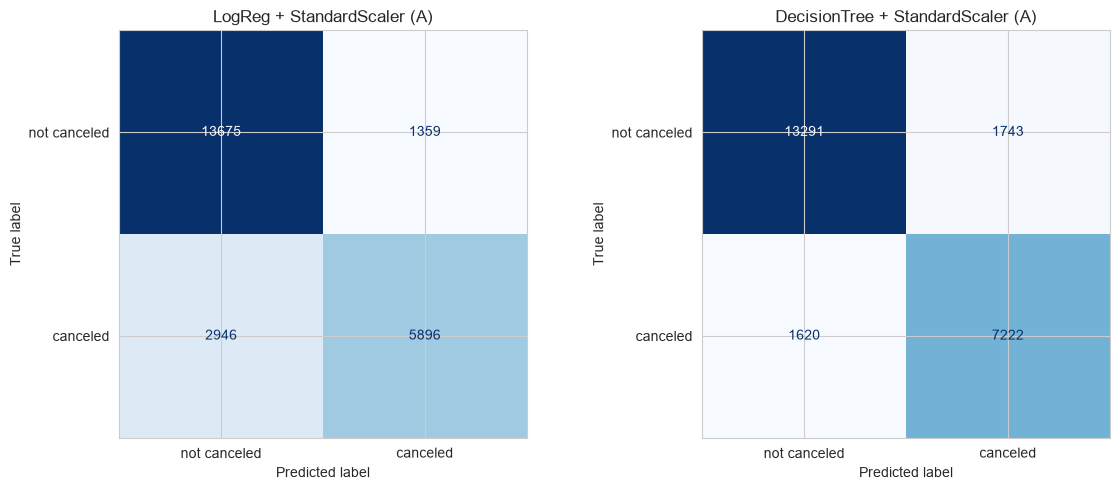

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name in zip(axes, [best_lr_name, best_dt_name]):
    pipe = models[name]
    preds = pipe.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['not canceled', 'canceled'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.show()


In [21]:
# quick look at overfitting - just the train/test gap column from the table above
results_df[['model_pipeline', 'train_acc', 'test_acc', 'train_test_gap']]


,model_pipeline,train_acc,test_acc,train_test_gap
0,DecisionTree + StandardScaler (A),0.9962,0.8591,0.1370
1,DecisionTree + MinMaxScaler (B),0.9962,0.8587,0.1375
2,LogReg + StandardScaler (A),0.8186,0.8197,-0.0011
3,LogReg + MinMaxScaler (B),0.8146,0.8158,-0.0011


Whichever row has the biggest `train_test_gap` is overfitting the most - normally that ends up
being one of the Decision Tree runs since an unpruned tree memorizes the training set easily, while
Logistic Regression's gap usually stays small since it's a simpler, higher-bias model.

### Task 6 - Final observations

*(fill this in after running the notebook on the actual csv and looking at `results_df` +
the two confusion matrices above - the points below are the ones to check for/comment on)*

1. **Best overall combination:** whichever row in `results_df` has the highest test F1 (not just
   accuracy, since the classes aren't perfectly balanced) - state which one it is and why.
2. **StandardScaler vs MinMaxScaler for Logistic Regression:** compare the two LogReg rows - scaling
   choice usually moves LogReg's metrics a bit since it's a distance/gradient-based model, note which
   scaler did better and roughly by how much.
3. **Does scaling matter for the Decision Tree:** compare the two DT rows - trees split on thresholds
   feature by feature, so scaling normally makes almost no difference; confirm that's what happened here.
4. **Overfitting:** point to the `train_test_gap` column - call out whichever model has the largest gap
   and connect it back to model complexity (deep unpruned tree vs. a simpler linear model).
5. **Precision/recall trade-off:** look at the confusion matrices - mention whether false positives or
   false negatives are more common for each model and what that means in a hotel-cancellation-prediction
   context (e.g. missing an actual cancellation vs. flagging a booking that wasn't going to cancel).